# Анализ работы библиотеки с полносвязными нейронными сетями на С++

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Сравним, скорость обучения при разных размерах батча (был запущен код на С++ и скопированы значения точности на тестовой выборке)

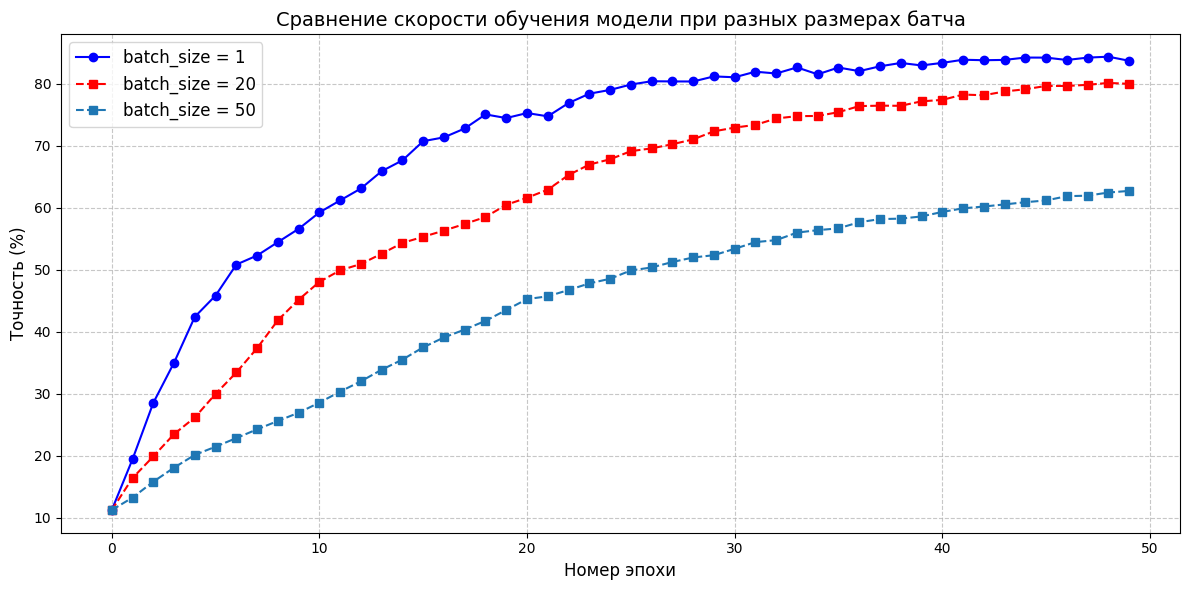

In [9]:
data1 = np.array([11.26000, 19.46000, 28.55000, 35.04000, 42.43000, 45.86000, 50.86000, 52.32000, 54.48000, 56.62000, 59.27000, 61.21000, 63.13000, 65.92000, 67.67000, 70.76000, 71.38000, 72.81000, 75.08000, 74.49000, 75.30000, 74.77000, 76.91000, 78.42000, 79.03000, 79.90000, 80.43000, 80.40000, 80.39000, 81.21000, 81.07000, 81.97000, 81.68000, 82.66000, 81.55000, 82.64000, 82.06000, 82.84000, 83.38000, 82.98000, 83.39000, 83.90000, 83.82000, 83.87000, 84.25000, 84.24000, 83.86000, 84.24000, 84.39000, 83.73000])
data2 = np.array([11.26000,
16.42000,
19.91000,
23.51000,
26.20000,
30.00000,
33.45000,
37.37000,
41.88000,
45.19000,
48.07000,
49.93000,
50.95000,
52.61000,
54.35000,
55.34000,
56.34000,
57.41000,
58.53000,
60.50000,
61.63000,
62.94000,
65.30000,
66.99000,
67.84000,
69.15000,
69.60000,
70.27000,
71.05000,
72.35000,
72.95000,
73.39000,
74.42000,
74.80000,
74.83000,
75.44000,
76.42000,
76.49000,
76.47000,
77.19000,
77.42000,
78.28000,
78.17000,
78.78000,
79.14000,
79.67000,
79.67000,
79.85000,
80.16000,
80.01000])

data3 = np.array([11.26000,
13.27000,
15.83000,
18.10000,
20.16000,
21.48000,
22.87000,
24.28000,
25.63000,
26.96000,
28.59000,
30.37000,
32.03000,
33.90000,
35.53000,
37.51000,
39.10000,
40.38000,
41.78000,
43.53000,
45.29000,
45.74000,
46.75000,
47.82000,
48.57000,
49.91000,
50.39000,
51.27000,
52.00000,
52.37000,
53.40000,
54.48000,
54.80000,
56.01000,
56.41000,
56.70000,
57.69000,
58.19000,
58.27000,
58.62000,
59.35000,
59.93000,
60.22000,
60.56000,
60.92000,
61.20000,
61.89000,
61.97000,
62.48000,
62.74000])

x = np.arange(len(data1))
plt.figure(figsize=(12, 6))
plt.plot(x, data1, marker='o', linestyle='-', color='b', label='batch_size = 1')
plt.plot(x, data2, marker='s', linestyle='--', color='r', label='batch_size = 20')
plt.plot(x, data3, marker='s', linestyle='--', label='batch_size = 50')
plt.xlabel('Номер эпохи', fontsize=12)
plt.ylabel('Точность (%)', fontsize=12)
plt.title('Сравнение скорости обучения модели при разных размерах батча', fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Теперь небольшое сравнение с полносвязными нейронными сетями на  Python

In [12]:
import time
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

Загрузим датасет

In [17]:
def load_data(filename):
    df = pd.read_csv('mnist_train.csv', skiprows=1, header=None, dtype=str)
    df = df.apply(pd.to_numeric, errors='coerce')
    df.dropna(inplace=True)
    data = df.values
    X = data[:, 1:].astype('float32') / 255.0
    y = data[:, 0].astype(int)
    return X, y

In [18]:
X_train, y_train = load_data('mnist_train.csv')
X_test, y_test = load_data('mnist_test.csv')
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

Построим модель аналогичную модели из написанной на С++ библиотеки. Сравним скорость обучения и время при большом и маленьком размерах батча

Размер батча - 50:

In [22]:
model = Sequential([
    Dense(20, activation='sigmoid', input_shape=(784,)),
    Dense(10, activation='sigmoid')
])

optimizer = SGD(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['accuracy'])
epochs = 5
batch_size = 50
times = []

for epoch in range(epochs):
    start_time = time.time()
    model.fit(X_train, y_train, epochs=1, batch_size=batch_size, verbose=1)
    end_time = time.time()
    epoch_time = end_time - start_time
    times.append(epoch_time)

for i in range(len(times)):
  print(f'Epoch {i + 1} time: {times[i]:.5f} s')

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1021 - loss: 0.2670
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0961 - loss: 0.2253
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1004 - loss: 0.1931
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0988 - loss: 0.1696
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0972 - loss: 0.1524
Epoch 1 time: 2.64653 s
Epoch 2 time: 2.40293 s
Epoch 3 time: 5.52310 s
Epoch 4 time: 2.84994 s
Epoch 5 time: 2.85012 s


Размер батча - 2:

In [20]:
model = Sequential([
    Dense(20, activation='sigmoid', input_shape=(784,)),
    Dense(10, activation='sigmoid')
])

optimizer = SGD(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['accuracy'])
epochs = 5
batch_size = 2
times = []

for epoch in range(epochs):
    start_time = time.time()
    model.fit(X_train, y_train, epochs=1, batch_size=batch_size, verbose=1)
    end_time = time.time()
    epoch_time = end_time - start_time
    times.append(epoch_time)

for i in range(len(times)):
  print(f'Epoch {i + 1} time: {times[i]:.5f} s')


30000/30000 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.1305 - loss: 0.1597
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step - accuracy: 0.3120 - loss: 0.0902
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - accuracy: 0.3700 - loss: 0.0876
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 51s 2ms/step - accuracy: 0.3535 - loss: 0.0863
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - accuracy: 0.3588 - loss: 0.0850
Epoch 1 time: 82.73160 s
Epoch 2 time: 82.22092 s
Epoch 3 time: 82.22287 s
Epoch 4 time: 51.73385 s
Epoch 5 time: 46.63506 s


Видим, что при маленьком размере батча скорость обучения больше (аналогичное наблюдалось и в С++), при большом после 5 эпох точность 0.0972, при маленьком - 0.3588). При этом при маленьком сильно страдает время, но С++ помогает избежать этой проблемы.